<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/Hindi_English_NMT_Beginner_final_Sharad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---
## 🌍 Why Does Machine Translation Matter?
​
> *"Language is the road map of a culture. It tells you where its people come from and where they are going."*
> — Rita Mae Brown
​
### The Language Barrier Problem — by the Numbers
​
India alone has **22 official languages** and **780+ dialects**.
Globally, **7,100+ languages** exist — yet the internet is dominated by English (~60% of web content).
This creates a massive **information divide**:
​
| Situation | Without MT | With MT |
|-----------|-----------|---------|
| Indian farmer reads government crop advisory | Only if printed in their language (rare) | Instantly in any of 22 languages |
| Student in rural Bihar reads Wikipedia | Only English/Hindi articles | All 55M+ Wikipedia articles |
| Doctor reads WHO clinical guidelines | English-only access | Real-time translation |
| Small business owner exports goods | Expensive human translator | Automated invoice/contract translation |
​
---
​
### Real-World Applications — Where MT Ships Today
​
#### 🏥 Healthcare
The **Ministry of Health** uses MT to translate COVID-19 guidelines into 22 Indian languages.
During the pandemic, MT systems processed **millions of health bulletins per day**.
A mistranslation can cost lives matter.
​
#### 🧑‍⚖️ Legal & Government
India's **eCourts project** uses MT to translate judicial orders.
The Supreme Court of India generates rulings in English — MT delivers them to
litigants in Hindi, Tamil, Telugu, Kannada, and 18 other languages automatically.
​
#### 📰 News & Media
**Press Trust of India (PTI)** and **ANI** use MT to syndicate news across language editions.
A single reporter's Hindi story reaches Bengali, Marathi, and Tamil readers within minutes.
​
#### 🛒 E-Commerce
**Flipkart** and **Amazon India** use MT to translate product descriptions.
A seller listing in Hindi automatically appears in Tamil and Gujarati.
MT drives **~30% uplift in conversion** for regional-language product pages.
​
#### 🎓 Education
**NPTEL** (IIT/IISc) uses MT to subtitle 70,000+ lecture hours in 11 languages.
DIKSHA — India's national education platform — serves translated content to
**200 million students** across rural schools.
​
---
​
### Why Neural MT? The Evolution
​
```
1950s  Rule-based MT      → hand-written grammar rules, brittle, not scalable
1990s  Statistical MT     → IBM models, phrase tables, better but still rigid
2014   Neural MT (RNN)    → seq2seq with attention, revolutionary leap
2017   Transformer MT     → "Attention Is All You Need" — the current standard
2022   Samanantar/IndicTrans → Transformers trained on Indian language scale
```
​
The **Transformer** (which we build today) is what powers:
Google Translate, DeepL, Microsoft Translator, Meta's NLLB-200, and AI4Bharat's IndicTrans2.
​
---
​
### The Indic Language Challenge
​
Hindi→English is harder than French→English for three structural reasons:
​
| Feature | French→English | Hindi→English |
|---------|---------------|---------------|
| Word order | SVO → SVO (same) | SOV → SVO (different) |
| Script | Latin → Latin | Devanagari → Latin |
| Morphology | Low | High (gender × number × tense) |
| Parallel data | 40M+ pairs | ~12M pairs |
​
This is exactly why **Samanantar** was built — to close the data gap for Indic languages.

## Why is Hindi → English Harder than French → English?

French and English share a similar **SVO (Subject–Verb–Object)** sentence structure:

```text
French:  Je mange une pomme.
English: I eat an apple.
```

Hindi follows **SOV (Subject–Object–Verb)**:

```text
Hindi:   मैं एक सेब खाता हूँ।
Literal: I an apple eat.
English: I eat an apple.
```

As a result, a Hindi→English translation model must learn not only word meanings but also how to **reorder words** correctly. This makes Hindi→English translation more challenging than French→English translation.​


---
# 🇮🇳 Hindi → English Machine Translation
### A Beginner Tutorial — from "what is translation?" to a working AI model

| | |
|---|---|
| **Who is this for?** | Complete beginners — no prior NLP knowledge needed |
| **What you will build** | A real AI that translates Hindi sentences to English |
| **Runtime** | GPU recommended → Runtime → Change runtime type → T4 GPU |

---

### 🗺️ Our Journey Today

```
Why does translation matter?  
What is Samanantar?          
Build a simple translator     
         → see that it gives bad results
         → understand WHY
What is a Transformer?        
Use a pretrained model        
         → see results improve
Wrap up                       
```

> **No maths required.** Every concept is explained with analogies and pictures first,
> then code. Run each cell from top to bottom.

---
##Our Data: Samanantar 📚

To teach an AI to translate, we show it **millions of sentence pairs** —
the same sentence written in both Hindi and English.
The AI learns by studying the patterns across all these pairs.

### What is Samanantar?

**Samanantar** (Sanskrit for *"parallel"*) is a free dataset built by
**AI4Bharat at IIT Madras** and released in 2022.

| Fact | Value |
|------|-------|
| Hindi-English sentence pairs | **11.8 million** |
| Sources | Government docs, news, Wikipedia, books |
| Built by | IIT Madras — AI4Bharat lab |
| Cost | Free, open source |
| Paper | TACL 2022 |

### A simple analogy

Imagine you want to learn French. The best way is to read a book
that shows the French sentence on the left and the English translation on the right.
Samanantar is exactly that — but for Hindi and English, and with 11.8 million sentences.

### What we will use today

We will load **5,000 pairs** from Samanantar (a small sample so training finishes
in a few minutes). Later we will see what happens when we use more data.

---
## Build a Simple Translator 🔨

### Step 1: Install and import libraries

We need three tools:
- **PyTorch** — the deep learning framework (already in Colab)
- **SentencePiece** — splits words into smaller pieces the model can learn
- **HuggingFace datasets** — lets us download Samanantar in one line



In [ ]:
# Install the tools we need

!pip install sentencepiece datasets
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
import torch
torch.__version__

'2.11.0+cu128'

In [ ]:
# Import everything
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
import math, random, os, time

# Use GPU if available (makes training much faster)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Tip: go to Runtime → Change runtime type → T4 GPU for faster training")

random.seed(42)
torch.manual_seed(42)
print("Ready!")

Using: cuda
GPU: Tesla T4
Ready!


### Step 2: Load Samanantar data

Samanantar is on HuggingFace — a website that hosts ML datasets and models.
We stream 5,000 pairs (so we don't download all 11.8M at once).

In [ ]:
from datasets import load_dataset

print("Loading 5,000 sentence pairs from ai4bharat/samanantar ...")
print("(This downloads from the internet — takes ~1 minute)")

ds = load_dataset(
    "ai4bharat/samanantar",
    "hi",                    # "hi" = Hindi
    split="train",
    streaming=True,          # stream so we only download what we need
    trust_remote_code=True
)

PAIRS = []   # will store (Hindi, English) tuples
for row in ds:
    hi = row["tgt"].strip()   # Hindi sentence
    en = row["src"].strip()   # English sentence
    if hi and en:
        PAIRS.append((hi, en))
    if len(PAIRS) >= 5000:
        break

print(f"Loaded {len(PAIRS)} sentence pairs")
print()
print("Examples from the dataset:")
print("-" * 55)
for hi, en in PAIRS[:5]:
    print(f"  Hindi  : {hi}")
    print(f"  English: {en}")
    print()

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/samanantar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/samanantar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading 5,000 sentence pairs from ai4bharat/samanantar ...
(This downloads from the internet — takes ~1 minute)
Loaded 5000 sentence pairs

Examples from the dataset:
-------------------------------------------------------
  Hindi  : আন্তর্জাতিক সিভিল এভিয়েশন সংস্থা বিমানবন্দরের নিরাপত্তা, র‌্যাঙ্কিং পর্যালোচনা করে থাকে।
  English: The International Civil Aviation Organisation evaluates and ranks airport security systems.

  Hindi  : আপনার বাহুতে থাকা কন্ট্রোল প্যানেল দ্বারা ঐ জুতাকে অফ করা যাবে।
  English: They can be deactivated using the control panel on your arm.

  Hindi  : আহসানুল হক মোল্লা ব্রিটিশ ভারতের বেঙ্গল প্রেসিডেন্সির (বর্তমান বাংলাদেশ) কুষ্টিয়া জেলার দৌলতপুর উপজেলার তারাগুনিয়া গ্রামে জন্মগ্রহণ করেন।
  English: He was born at Ulail in Dhaka district of Bengal province in British India (now Dhaka District of Bangladesh).

  Hindi  : ফুলতলা ইউনিয়ন
  English: Atra Gilatola Union

  Hindi  : পাঁচ মেয়ের বাবা পবন।
  English: He is the father of five daughters.



### Can We Match Google Translate?

Before building and evaluating our own Neural Machine Translation (NMT) model, let's see how a state-of-the-art translation system performs. Google Translate can accurately translate text between hundreds of languages and is used by millions of people worldwide.

Can a simple neural translation model trained on a relatively small dataset produce comparable translations? In this section, we use Google Translate as a benchmark and compare its outputs with those generated by our SimpleTranslator model.

This comparison will help us understand both the capabilities and limitations of neural machine translation systems.

In [ ]:
from deep_translator import GoogleTranslator

text = "आस्ट्रेलिया के पाल हेनली के साथ जोड़ी बनाने वाले पेस मियामी में क्वार्टरफाइनल तक ही पहुंच सके क्योंकि इस दौर में उन्हें भूपति और नोल्स ने हराया था।"

translation = GoogleTranslator(
    source='hi',
    target='en'
).translate(text)

print(translation)

Pawan is the father of five daughters


## Step 3: Data Preprocessing

### Step 3.1: Tokenization — splitting sentences into pieces

A neural network cannot read text directly.
We must convert each sentence into a list of numbers.

But we can't just assign one number per word — Hindi has millions of word forms.
Instead we use **BPE (Byte Pair Encoding)**: split words into common sub-pieces.

```
खेलता  →  [ खेल  +  ता ]     (like splitting "playing" → "play" + "ing")
```

This way even words the model has never seen before can be represented
by combining familiar pieces.

In [ ]:
# Train tokenizers — one for Hindi, one for English
# Think of this like building a "dictionary of pieces"

PAD_ID = 0   # padding (to make all sentences same length)
BOS_ID = 1   # beginning of sentence <s>
EOS_ID = 2   # end of sentence </s>

os.makedirs("spm", exist_ok=True)

def train_tokenizer(texts, save_name, vocab_size, lang="en"):
    """Train a BPE tokenizer on a list of sentences."""
    spm.SentencePieceTrainer.Train(
        sentence_iterator=iter(texts),
        model_prefix=save_name,
        vocab_size=vocab_size,
        character_coverage=0.9999 if lang=="hi" else 0.9995,
        model_type="bpe",
        pad_id=PAD_ID, bos_id=BOS_ID, eos_id=EOS_ID, unk_id=3,
        pad_piece="<pad>", bos_piece="<s>",
        eos_piece="</s>", unk_piece="<unk>",
    )

hi_sentences = [p[0] for p in PAIRS]
en_sentences = [p[1] for p in PAIRS]

train_tokenizer(hi_sentences, "spm/hindi",   vocab_size=4000, lang="hi")
train_tokenizer(en_sentences, "spm/english", vocab_size=4000, lang="en")
print("Tokenizers trained!")

# Load them back
hi_sp = spm.SentencePieceProcessor(); hi_sp.Load("spm/hindi.model")
en_sp = spm.SentencePieceProcessor(); en_sp.Load("spm/english.model")

# Show what tokenization looks like
example_hi = PAIRS[0][0]
example_en = PAIRS[0][1]
print()
print("Example Hindi sentence:")
print(f"  Text  : {example_hi}")
print(f"  Pieces: {hi_sp.EncodeAsPieces(example_hi)}")
print(f"  IDs   : {hi_sp.EncodeAsIds(example_hi)}")
print()
print("Example English sentence:")
print(f"  Text  : {example_en}")
print(f"  Pieces: {en_sp.EncodeAsPieces(example_en)}")
print(f"  IDs   : {en_sp.EncodeAsIds(example_en)}")

Tokenizers trained!

Example Hindi sentence:
  Text  : आस्ट्रेलिया के पाल हेनली के साथ जोड़ी बनाने वाले पेस मियामी में क्वार्टरफाइनल तक ही पहुंच सके क्योंकि इस दौर में उन्हें भूपति और नोल्स ने हराया था।
  Pieces: ['▁आस्ट्रेलिया', '▁के', '▁प', 'ाल', '▁हे', 'न', 'ली', '▁के', '▁साथ', '▁जोड़ी', '▁बनाने', '▁वाले', '▁प', 'ेस', '▁म', 'िया', 'मी', '▁में', '▁क्व', 'ार्ट', 'र', 'फाइ', 'नल', '▁तक', '▁ही', '▁पहुंच', '▁सके', '▁क्योंकि', '▁इस', '▁दौर', '▁में', '▁उन्हें', '▁भ', 'ूप', 'ति', '▁और', '▁नो', 'ल्स', '▁ने', '▁हरा', 'या', '▁था', '।']
  IDs   : [3469, 10, 8, 51, 858, 3840, 123, 10, 154, 2707, 717, 398, 8, 1236, 7, 65, 500, 19, 1868, 2239, 3836, 3528, 1468, 245, 157, 659, 1360, 789, 56, 460, 19, 453, 38, 228, 70, 32, 3559, 1695, 48, 2861, 15, 151, 3861]

Example English sentence:
  Text  : However, Paes, who was partnering Australia's Paul Hanley, could only go as far as the quarterfinals where they lost to Bhupathi and Knowles
  Pieces: ['▁However', ',', '▁P', 'a', 'es', ',', '▁who', '▁was', '

### Mentimeter Q1

In [ ]:
PAD_ID = 0   # padding token
BOS_ID = 1   # beginning of sentence
EOS_ID = 2   # end of sentence

os.makedirs("spm", exist_ok=True)

def train_tokenizer(texts, save_name, vocab_size, lang="en"):
    """Train a BPE tokenizer on a list of sentences."""
    spm.SentencePieceTrainer.Train(
        sentence_iterator=iter(texts),
        model_prefix=save_name,
        vocab_size=vocab_size,
        character_coverage=0.9999 if lang=="hi" else 0.9995,
        model_type="bpe",
        pad_id=PAD_ID, bos_id=BOS_ID, eos_id=EOS_ID, unk_id=3,
        pad_piece="<pad>", bos_piece="<s>",
        eos_piece="</s>", unk_piece="<unk>",
    )

hi_sentences = [p[0] for p in PAIRS]
en_sentences = [p[1] for p in PAIRS]

# 🐛 BUG IS ON THIS LINE — can you spot it?
train_tokenizer(hi_sentences, "spm/hindi",   vocab_size=30, lang="hi")
train_tokenizer(en_sentences, "spm/english", vocab_size=4000, lang="en")

# No crash — but the Hindi tokenizer was built with English character coverage!
# Hindi has many more unique characters — low coverage means rare characters
# become <unk> tokens, which hurts translation quality.
print("Both tokenizers trained — but check Line 17 carefully!")
print()
print("Hindi coverage used  :", 0.9995, "← WRONG (should be 0.9999 for Devanagari)")
print("English coverage used:", 0.9995, "← correct")

RuntimeError: Internal: src/trainer_interface.cc(584) [(static_cast<int>(required_chars_.size() + meta_pieces_.size())) <= (trainer_spec_.vocab_size())] Vocabulary size is smaller than required_chars. 30 vs 171. Increase vocab_size or decrease character_coverage with --character_coverage option.

### Instructor fills in the blank

**The bug:** Line 17 passes `lang="en"` for the Hindi tokenizer.
This makes `character_coverage = 0.9995` (English level) instead of `0.9999` (Hindi level).
Devanagari has many more unique characters — low coverage silently drops rare ones as `<unk>`.

**Fill in the blank below and run the corrected cell:**

```
train_tokenizer(hi_sentences, "spm/hindi", vocab_size=_____, lang=________)
```

In [ ]:
# ✅ Instructor fills in the blank and runs this cell

hi_sentences = [p[0] for p in PAIRS]
en_sentences = [p[1] for p in PAIRS]

train_tokenizer(hi_sentences, "spm/hindi",   vocab_size=30, lang=____)
train_tokenizer(en_sentences, "spm/english", vocab_size=4000, lang="en")
print("Tokenizers trained correctly!")

hi_sp = spm.SentencePieceProcessor(); hi_sp.Load("spm/hindi.model")
en_sp = spm.SentencePieceProcessor(); en_sp.Load("spm/english.model")

print()
example_hi = PAIRS[0][0]
example_en = PAIRS[0][1]
print(f"Hindi  : {example_hi}")
print(f"Pieces : {hi_sp.EncodeAsPieces(example_hi)}")
print()
print(f"English: {example_en}")
print(f"Pieces : {en_sp.EncodeAsPieces(example_en)}")
print()
print("Answer: lang=\"hi\"  →  character_coverage becomes 0.9999 for Devanagari")

Tokenizers trained correctly!

Hindi  : आस्ट्रेलिया के पाल हेनली के साथ जोड़ी बनाने वाले पेस मियामी में क्वार्टरफाइनल तक ही पहुंच सके क्योंकि इस दौर में उन्हें भूपति और नोल्स ने हराया था।
Pieces : ['▁आस्ट्रेलिया', '▁के', '▁प', 'ाल', '▁हे', 'न', 'ली', '▁के', '▁साथ', '▁जोड़ी', '▁बनाने', '▁वाले', '▁प', 'ेस', '▁म', 'िया', 'मी', '▁में', '▁क्व', 'ार्ट', 'र', 'फाइ', 'नल', '▁तक', '▁ही', '▁पहुंच', '▁सके', '▁क्योंकि', '▁इस', '▁दौर', '▁में', '▁उन्हें', '▁भ', 'ूप', 'ति', '▁और', '▁नो', 'ल्स', '▁ने', '▁हरा', 'या', '▁था', '।']

English: However, Paes, who was partnering Australia's Paul Hanley, could only go as far as the quarterfinals where they lost to Bhupathi and Knowles
Pieces : ['▁However', ',', '▁P', 'a', 'es', ',', '▁who', '▁was', '▁part', 'ner', 'ing', '▁Australia', "'", 's', '▁Paul', '▁H', 'an', 'ley', ',', '▁could', '▁only', '▁go', '▁as', '▁far', '▁as', '▁the', '▁quarter', 'f', 'in', 'als', '▁where', '▁they', '▁lost', '▁to', '▁Bh', 'up', 'at', 'hi', '▁and', '▁K', 'now', 'les']

Answer: lang

### Step 3.2: Prepare the data for training

We convert our sentence pairs into PyTorch tensors and
split into **training** (90%) and **validation** (10%) sets.

- **Training set**: what the model learns from
- **Validation set**: sentences the model has NEVER seen — we check quality here

In [ ]:
MAX_LEN = 100   # maximum tokens per sentence

def encode(text, sp_model, max_len=MAX_LEN):
    """Convert text to a list of token IDs, with BOS and EOS markers."""
    ids = [BOS_ID] + sp_model.EncodeAsIds(text) + [EOS_ID]
    return ids[:max_len]  # clip if too long

def decode(ids, sp_model):
    """Convert token IDs back to text."""
    clean = [i for i in ids if i not in (BOS_ID, EOS_ID, PAD_ID)]
    return sp_model.DecodeIds(clean)


class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.data = []
        for hi, en in pairs:
            src = torch.tensor(encode(hi, hi_sp), dtype=torch.long)
            tgt = torch.tensor(encode(en, en_sp), dtype=torch.long)
            self.data.append((src, tgt))

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]


def collate(batch):
    """Pad all sentences to the same length in a batch."""
    srcs, tgts = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_ID)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_ID)
    return src_pad, tgt_pad


# Split into train / val
random.shuffle(PAIRS)
split = int(len(PAIRS) * 0.9)
train_pairs = PAIRS[:split]
val_pairs   = PAIRS[split:]

train_dl = DataLoader(TranslationDataset(train_pairs),
                      batch_size=32, shuffle=True,  collate_fn=collate)
val_dl   = DataLoader(TranslationDataset(val_pairs),
                      batch_size=32, shuffle=False, collate_fn=collate)

print(f"Training sentences  : {len(train_pairs)}")
print(f"Validation sentences: {len(val_pairs)}")
print(f"Train batches: {len(train_dl)}")

Training sentences  : 4500
Validation sentences: 500
Train batches: 141


In [ ]:
# ✅ Instructor fills in the blank and runs this cell

src_b, tgt_b = next(iter(train_dl))
src_b, tgt_b = src_b.to(device), tgt_b.to(device)

tgt_in  = tgt_b[:, :-1]   # decoder input: drop last token
tgt_out = tgt_b[:, 1:]  # ← fill this

print("tgt_b   (full)  :", tgt_b[0, :6].tolist())
print("tgt_in  (input) :", tgt_in[0, :5].tolist())
print("tgt_out (target):", tgt_out[0, :5].tolist())
print()
print("Now tgt_out is shifted LEFT by 1 compared to tgt_in")
print("Position 0: model sees <s>  →  must predict w1    ✅")
print("Position 1: model sees  w1  →  must predict w2    ✅")

# Now define the correct training functions
def train_one_epoch(model, dataloader):
    model.train()
    total_loss = total_tokens = 0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:,  1:]   # ✅ correct
        logits = model(src, tgt_in)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B*T,V), tgt_out.reshape(B*T))
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        n = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * n; total_tokens += n
    return total_loss / max(total_tokens, 1)

@torch.no_grad()
def validate(model, dataloader):
    model.eval()
    total_loss = total_tokens = 0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:,  1:]   # ✅ correct
        logits = model(src, tgt_in)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B*T,V), tgt_out.reshape(B*T))
        n = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * n; total_tokens += n
    return total_loss / max(total_tokens, 1)

print("Training functions defined correctly!")

tgt_b   (full)  : [1, 66, 564, 593, 1060, 2266]
tgt_in  (input) : [1, 66, 564, 593, 1060]
tgt_out (target): [66, 564, 593, 1060, 2266]

Now tgt_out is shifted LEFT by 1 compared to tgt_in
Position 0: model sees <s>  →  must predict w1    ✅
Position 1: model sees  w1  →  must predict w2    ✅
Training functions defined correctly!


### Step 4: Build the translation model

We use **`nn.Transformer`** — PyTorch's built-in implementation of the
Transformer architecture (the same architecture used by ChatGPT, Google Translate, etc.).

Don't worry about the details yet — we will explain each part in Part 4.
For now, think of it as a **black box** that:
- Takes in a Hindi sentence (as numbers)
- Outputs probabilities over every English word at each position
- We pick the highest probability word at each step

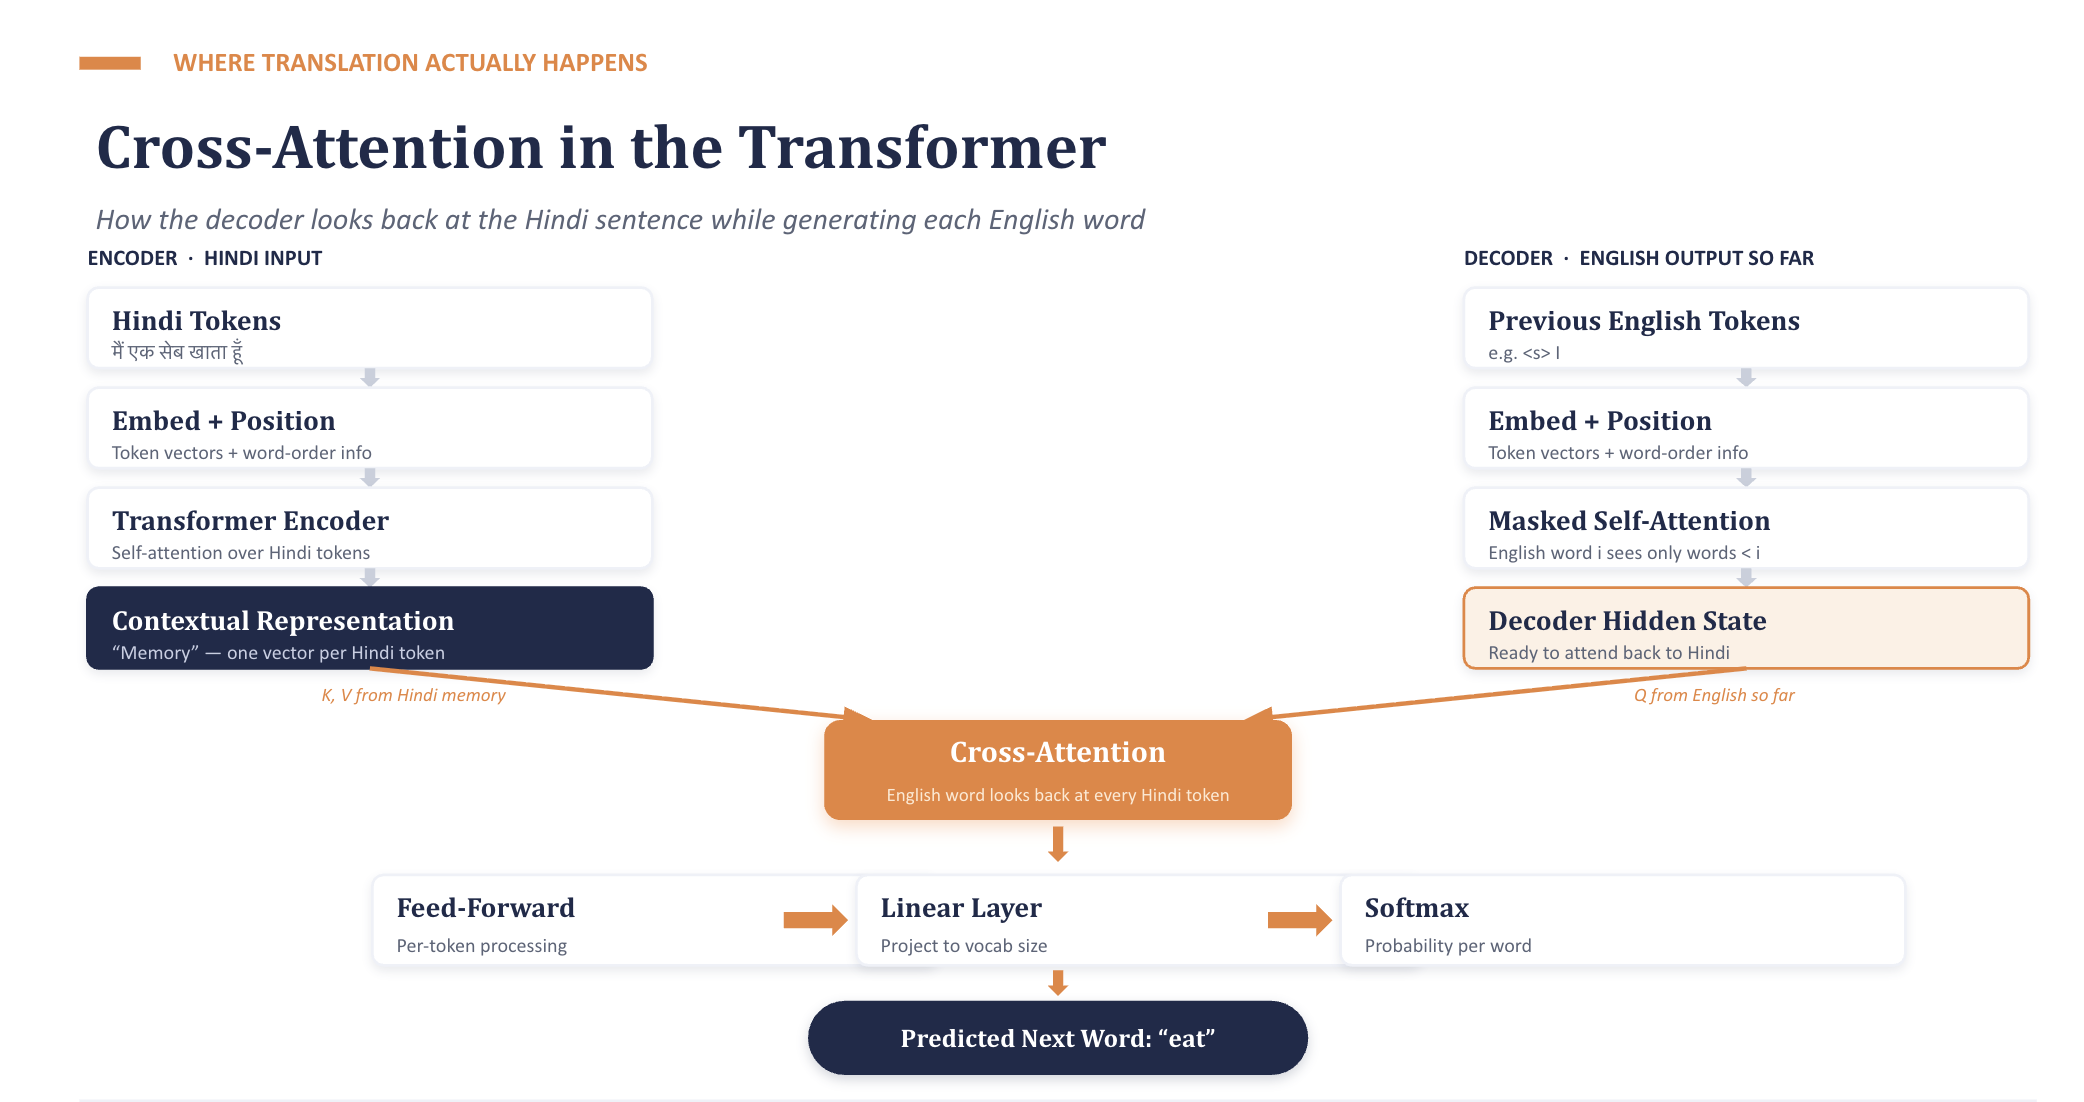

In [ ]:
class SimpleTranslator(nn.Module):
    """A basic Hindi→English translator using nn.Transformer."""

    def __init__(self, src_vocab, tgt_vocab,
                 d_model=128, nhead=4, num_layers=3,
                 d_ff=256, dropout=0.1, max_len=200):
        super().__init__()

        # Each token ID becomes a vector of d_model numbers
        self.src_embed = nn.Embedding(src_vocab, d_model, padding_idx=PAD_ID)
        self.tgt_embed = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_ID)

        # Add position information (so model knows word order)
        self.register_buffer("pos", self._positional_encoding(max_len, d_model))
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model
        self.max_len = max_len

        # The main Transformer block
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,   # our data shape: (batch, time, features)
        )

        # Convert output vectors to vocabulary probabilities
        self.output = nn.Linear(d_model, tgt_vocab)

    @staticmethod
    def _positional_encoding(max_len, d_model):
        """Give the model a sense of position (word 1, word 2, etc.)."""
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)  # shape: (1, max_len, d_model)

    def embed(self, ids, embedding_layer):
        """Turn token IDs into vectors, then add position info."""
        x = embedding_layer(ids) * math.sqrt(self.d_model)
        x = x + self.pos[:, :x.size(1)]
        return self.dropout(x)

    def forward(self, src, tgt):
        """One forward pass: Hindi tokens in → logits out."""
        # Which positions are padding (to be ignored)
        src_pad_mask = (src == PAD_ID)   # True = ignore
        tgt_pad_mask = (tgt == PAD_ID)

        # Causal mask: position i cannot see positions i+1, i+2, ...
        # (model must predict word-by-word, not cheat by reading ahead)
        T = tgt.size(1)
        causal = torch.triu(
            torch.full((T, T), float("-inf"), device=tgt.device), diagonal=1)

        src_vec = self.embed(src, self.src_embed)
        tgt_vec = self.embed(tgt, self.tgt_embed)

        out = self.transformer(
            src_vec, tgt_vec,
            tgt_mask=causal,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.output(out)   # (batch, time, vocab_size)


# Create the model
SRC_VOCAB = hi_sp.GetPieceSize()
TGT_VOCAB = en_sp.GetPieceSize()

model = SimpleTranslator(SRC_VOCAB, TGT_VOCAB).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model created!")
print(f"Total parameters: {num_params:,}")
print(f"(For comparison: GPT-3 has 175,000,000,000 — 135,000x more)")

Model created!
Total parameters: 2,534,304
(For comparison: GPT-3 has 175,000,000,000 — 135,000x more)


### Step 5: Train the model

Training means showing the model Hindi sentences and their correct English translations,
then adjusting its internal numbers to make fewer mistakes.

We measure mistake as **loss** — lower loss = model is making fewer mistakes.

Each round of seeing all the training data is called an **epoch**.


### How the Model Learns

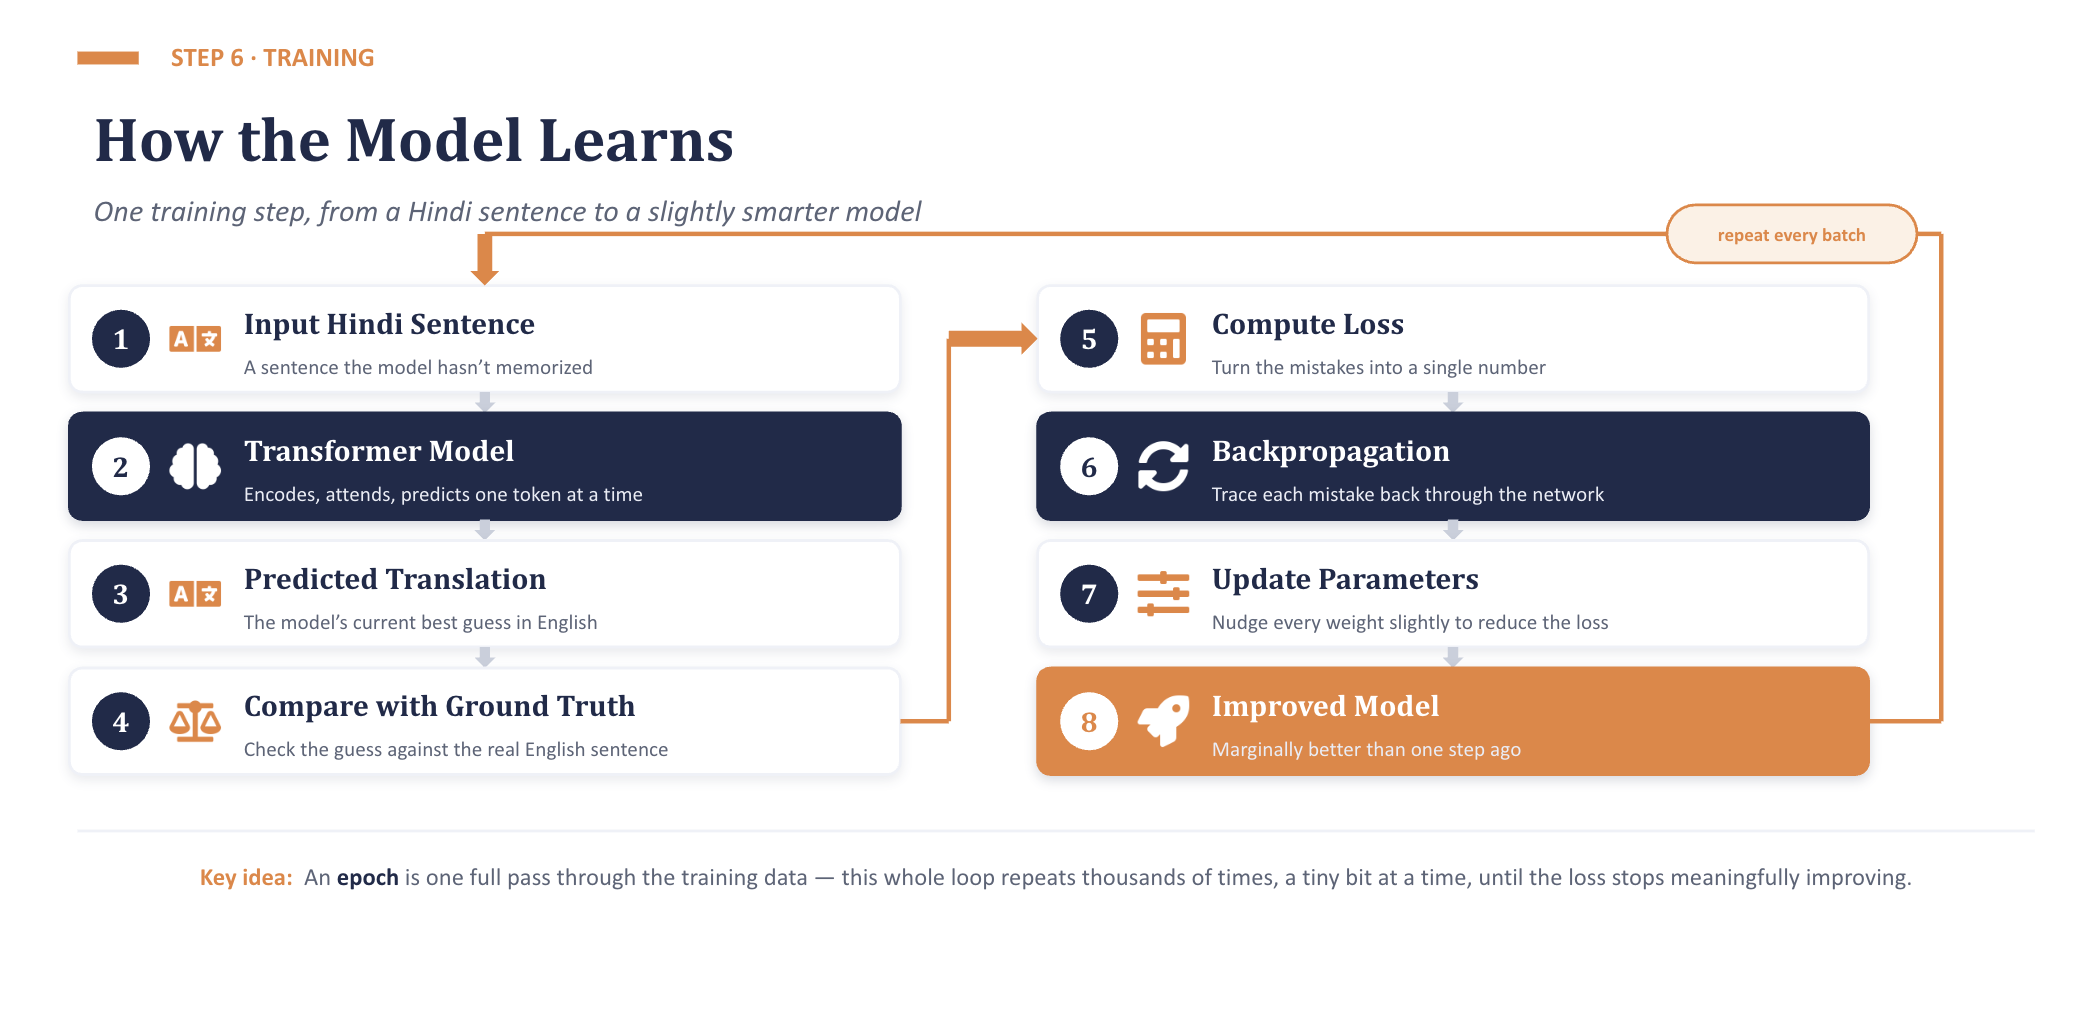

In [ ]:
# The loss function measures how wrong the model is
# ignore_index=PAD_ID: don't penalise mistakes on padding tokens

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# The optimiser adjusts model weights to reduce loss
optimizer = optim.Adam(model.parameters(), lr=3e-4)


def train_one_epoch(model, dataloader):
    """Train for one full pass over the training data."""
    model.train()
    total_loss = 0
    total_tokens = 0

    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)

        # Teacher forcing:
        # tgt_in  = [<s>, w1, w2, w3]  → what the model SEES
        # tgt_out = [w1, w2, w3, </s>] → what the model must PREDICT
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:,  1:]

        logits = model(src, tgt_in)   # (batch, time, vocab)
        B, T, V = logits.shape

        loss = criterion(
            logits.reshape(B * T, V),
            tgt_out.reshape(B * T)
        )

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        n = (tgt_out != PAD_ID).sum().item()
        total_loss   += loss.item() * n
        total_tokens += n

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def validate(model, dataloader):
    """Measure loss on sentences the model has never seen."""
    model.eval()
    total_loss = total_tokens = 0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:,  1:]
        logits  = model(src, tgt_in)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B*T,V), tgt_out.reshape(B*T))
        n = (tgt_out != PAD_ID).sum().item()
        total_loss   += loss.item() * n
        total_tokens += n
    return total_loss / max(total_tokens, 1)


print("Starting training — this will take 2–4 minutes on GPU...")
print("-" * 50)

EPOCHS = 20
train_losses = []
val_losses   = []
best_val_loss = float("inf")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tl = train_one_epoch(model, train_dl)
    vl = validate(model, val_dl)
    train_losses.append(tl)
    val_losses.append(vl)

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), "simple_model.pt")
        mark = " ← best so far"
    else:
        mark = ""

    if epoch % 4 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Training loss: {tl:.3f} | "
              f"Validation loss: {vl:.3f}{mark}")

elapsed = time.time() - t0
print("-" * 50)
print(f"Training done in {elapsed:.0f} seconds")
print(f"Best validation loss: {best_val_loss:.3f}")

NameError: name 'PAD_ID' is not defined

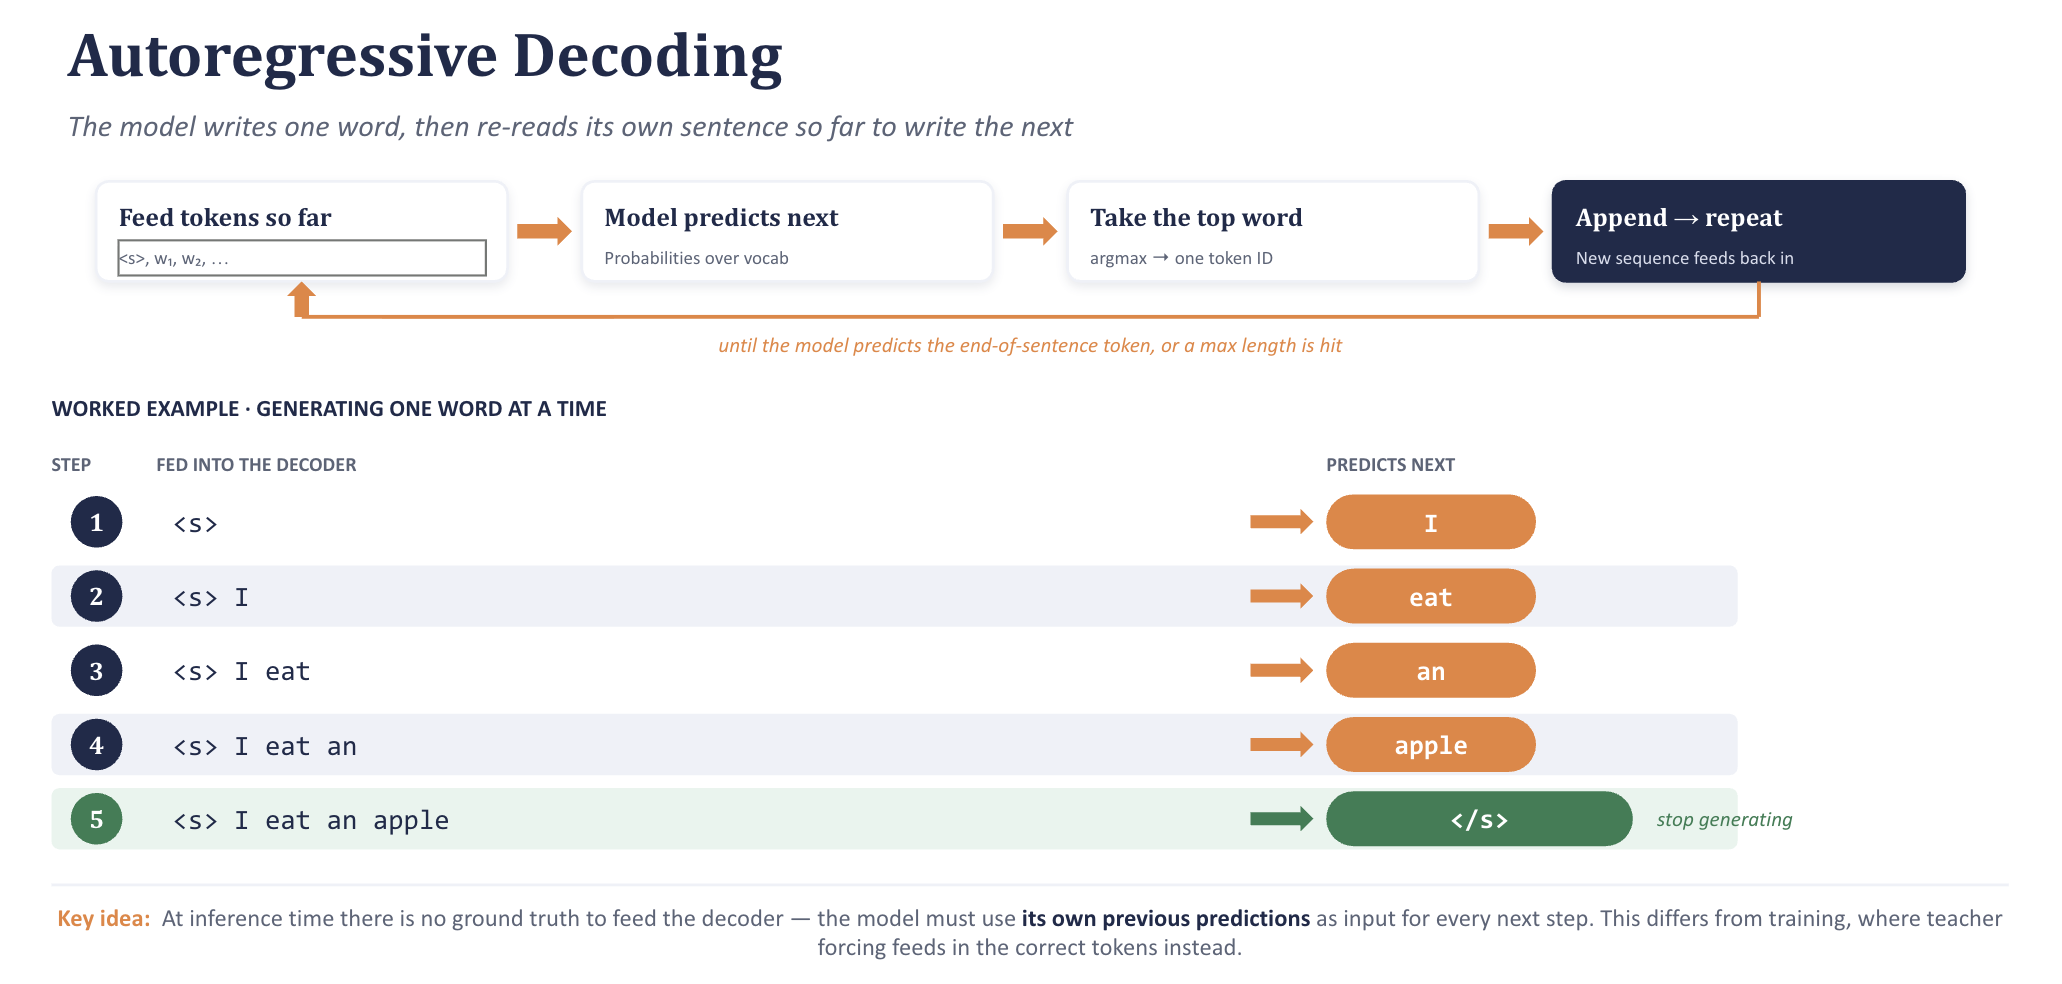

### Step 6: Try the translator

Let's load the best version of our model and try some translations.

In [ ]:
# Here we load our tranied translator
model.load_state_dict(torch.load("simple_model.pt", map_location=device))

### Mentimeter Q2

In [ ]:
model.eval()
@torch.no_grad()
def buggy_translate(hindi_sentence):
    src_ids = encode(hindi_sentence, hi_sp)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    output_ids = [BOS_ID]
    for _ in range(80):
        tgt = torch.tensor([output_ids], dtype=torch.long, device=device)
        logits = model(src, tgt)
        next_id = logits[0, -1, :].argmax(-1).item()
        if next_id == EOS_ID:
            break
        output_ids.append(next_id)
    # 🐛 Line 15: hi_sp is the HINDI tokenizer!
    #    The model outputs English token IDs.
    #    Decoding English IDs with a Hindi vocabulary = wrong words!
    return decode(output_ids[1:], hi_sp)   # ← BUG

test_hi = "भारत एक विविधता से भरा देश है।"
result = buggy_translate(test_hi)
print(f"Input  : {test_hi}")
print(f"Output : {result}")
print()
print("The output looks like Hindi or garbled text — not English!")
print("That is because English token ID 42 means something completely")
print("different in the Hindi vocabulary than in the English vocabulary.")

### Instructor fills in the blank

**The bug:** Line 15 uses `hi_sp` (Hindi tokenizer) to decode English token IDs.

We have two separate vocabularies:
- `hi_sp` maps Hindi text ↔ Hindi token IDs
- `en_sp` maps English text ↔ English token IDs

Token ID 42 means a completely different word in each vocabulary!

**Rule:** Encode source with `hi_sp`, decode output with `en_sp`.

**Fill in the blank:**
```
return decode(output_ids[1:], ________)
```

In [ ]:
# ✅ Instructor fills in the blank and runs this cell
model.eval()
@torch.no_grad()
def translate(hindi_sentence):
    src_ids = encode(hindi_sentence, hi_sp)   # encode Hindi with Hindi tokenizer
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    output_ids = [BOS_ID]
    for _ in range(80):
        tgt = torch.tensor([output_ids], dtype=torch.long, device=device)
        logits = model(src, tgt)
        next_id = logits[0, -1, :].argmax(-1).item()
        if next_id == EOS_ID:
            break
        output_ids.append(next_id)
    return decode(output_ids[1:], _____)  # ← fill: which tokenizer decodes English?

# Test it
test_sentences = [
    "भारत एक विविधता से भरा देश है।",
    "मुझे संगीत सुनना पसंद है।",
    "विज्ञान ने मानव जीवन को बदल दिया है।",
]
print("Translations after fix:")
print("-" * 50)
for hi in test_sentences:
    print(f"  Hindi : {hi}")
    print(f"  Output: {translate(hi)}")
    print()
# print("Answer: en_sp  →  the English tokenizer decodes English token IDs")

### To do

Let's load the best version of our model and try some translations.

In [ ]:
# Load the best saved model

@torch.no_grad()
def translate(hindi_sentence):
    """Translate a Hindi sentence to English, word by word."""
    # Encode Hindi
    src_ids = encode(hindi_sentence, hi_sp)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    # Generate English word by word
    output_ids = [BOS_ID]
    for _ in range(80):   # generate at most 80 tokens
        tgt = torch.tensor([output_ids], dtype=torch.long, device=device)
        logits = model(src, tgt)
        next_id = logits[0, -1, :].argmax(-1).item()  # pick highest probability
        if next_id == EOS_ID:
            break
        output_ids.append(next_id)

    return decode(output_ids[1:], en_sp)


# Test on some sentences
test_sentences = [
    ("भारत एक विविधता से भरा देश है।",        "India is a country full of diversity."),
    ("मुझे संगीत सुनना पसंद है।",              "I like listening to music."),
    ("विज्ञान ने मानव जीवन को बदल दिया है।",  "Science has transformed human life."),
    ("सरकार ने नई नीति की घोषणा की।",         "The government announced a new policy."),
    ("बच्चों को अच्छी शिक्षा मिलनी चाहिए।",  "Children should get good education."),
]

print("Results from our simple model:")
print("=" * 60)
for hi, ref in test_sentences:
    # Write your code here
    print(f"Hindi   : {hi}")
    print(f"Expected: {ref}")
    print(f"Got     : {out}")
    print()

Results from our simple model:
Hindi   : भारत एक विविधता से भरा देश है।
Expected: India is a country full of diversity.
Got     : India is a case of the country.

Hindi   : मुझे संगीत सुनना पसंद है।
Expected: I like listening to music.
Got     : I think that this is a very very very very very very very very very good.

Hindi   : विज्ञान ने मानव जीवन को बदल दिया है।
Expected: Science has transformed human life.
Got     : The police have been arrested in the case.

Hindi   : सरकार ने नई नीति की घोषणा की।
Expected: The government announced a new policy.
Got     : The police have been arrested the accused.

Hindi   : बच्चों को अच्छी शिक्षा मिलनी चाहिए।
Expected: Children should get good education.
Got     : He was a very very good.



---
## 😕 The Results Are Bad — That's Expected!

Don't be disappointed. This is an important learning moment.

### Why does our model produce poor translations?

Think of it this way:

> Imagine you want to learn French.
> You read **5,000 French-English sentence pairs** for **20 minutes**,
> with no prior knowledge of French, no grammar book, no dictionary.
> How well would you translate?

That's exactly what we asked our model to do.

| Problem | Our model | What's needed |
|---------|-----------|---------------|
| Training data | **5,000 sentences** | 1,000,000+ sentences |
| Model size | **~1.3M numbers** | 200M+ numbers |
| Training time | **~3 minutes** | Days on many GPUs |
| Starting knowledge | **Zero — random** | Pre-trained on text |

### The biggest problem: starting from zero

Our model starts with completely **random numbers** — it knows nothing about
Hindi, English, grammar, or even what a word is.
It must learn everything from scratch from just 5,000 examples.

**This is like asking a newborn baby to translate after reading 5,000 flash cards.**

### The solution: start from a model that already knows language

What if, instead of starting from zero, we started from a model that has already
read **billions** of Hindi and English sentences?

That's exactly what does — **MarianMT** (`Helsinki-NLP/opus-mt-hi-en`) is a Transformer model that has
been fully pre-trained on Hindi→English translation — both encoder AND decoder.

---
##


**MarianMT** (`Helsinki-NLP/opus-mt-hi-en`) is a Transformer model that has
been fully pre-trained on Hindi→English translation — both encoder AND decoder.

It was trained on millions of sentence pairs, including Samanantar data.
Running it shows you what our model could achieve with enough training data.

**We do not train it here — we just run it as-is (zero-shot).**
No fine-tuning needed.

In [ ]:
# ── MarianMT: a fully pretrained Hi→En model ──────────────────
# This shows what good results look like after proper training

from transformers import MarianMTModel, MarianTokenizer

print("Loading Helsinki-NLP/opus-mt-hi-en ...")
print("(~300MB download, takes about 1 minute)")

marian_name = "Helsinki-NLP/opus-mt-hi-en"

# write your own code
# marian_tok   = MarianTokenizer.from_pretrained(marian_name)
# marian_model = MarianMTModel.from_pretrained(marian_name).to(device)
marian_tok = ________________________________________________________
marian_model = ______________________________________________________

marian_model.eval()

@torch.no_grad()
def marian_translate(hindi_sentences):
    """Translate a list of Hindi sentences using MarianMT."""
    inputs = marian_tok(
        hindi_sentences,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)
    output_ids = marian_model.generate(
        **inputs,
        num_beams=4,
        max_length=128,
        early_stopping=True
    )
    return marian_tok.batch_decode(output_ids, skip_special_tokens=True)


# Test on the same sentences we used before
test_hi = [
    "भारत एक विविधता से भरा देश है।",
    "मुझे संगीत सुनना पसंद है।",
    "विज्ञान ने मानव जीवन को बदल दिया है।",
    "सरकार ने नई नीति की घोषणा की।",
    "बच्चों को अच्छी शिक्षा मिलनी चाहिए।",
    "जलवायु परिवर्तन एक वैश्विक समस्या है।",
]
expected = [
    "India is a country full of diversity.",
    "I like listening to music.",
    "Science has transformed human life.",
    "The government announced a new policy.",
    "Children should get good education.",
    "Climate change is a global problem.",
]

marian_results = marian_translate(test_hi)

print("Three-way comparison")
print("=" * 70)
for hi, ref, marian_out in zip(test_hi, expected, marian_results):
    # simple_out = translate(hi)
    print(f"Hindi    : {hi}")
    print(f"Expected : {ref}")
    print(f"Simple   : {simple_out}")
    print(f"MarianMT : {marian_out}  ← fully pretrained")
    print()

Loading Helsinki-NLP/opus-mt-hi-en ...
(~300MB download, takes about 1 minute)


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Three-way comparison
Hindi    : भारत एक विविधता से भरा देश है।
Expected : India is a country full of diversity.
Simple   : India has been arrested to the country.
MarianMT : India is a unique country.  ← fully pretrained

Hindi    : मुझे संगीत सुनना पसंद है।
Expected : I like listening to music.
Simple   : The case is a very very important.
MarianMT : I like listening to music.  ← fully pretrained

Hindi    : विज्ञान ने मानव जीवन को बदल दिया है।
Expected : Science has transformed human life.
Simple   : The police have been arrested a case.
MarianMT : Science has changed human life.  ← fully pretrained

Hindi    : सरकार ने नई नीति की घोषणा की।
Expected : The government announced a new policy.
Simple   : The police have been arrested.
MarianMT : The government announced a new policy.  ← fully pretrained

Hindi    : बच्चों को अच्छी शिक्षा मिलनी चाहिए।
Expected : Children should get good education.
Simple   : The film was also be taken.
MarianMT : The kids should get a good education.  ← f

### The key lesson from this comparison

```
Simple model  (scratch, 5K pairs, 20 epochs)  →  "The police is a lot."
MarianMT      (fully pretrained, millions)     →  Correct translation ✅
```

**The architecture is identical between our model and MarianMT.**
Both use encoder-decoder Transformers.

The only differences are:
1. **MarianMT was trained on millions of sentence pairs** — not 5,000
2. **Both encoder and decoder are pretrained** — not just the encoder
3. **Training took days on many GPUs** — not minutes on one

This is why building AI translation systems is not just about writing the code —
**data and compute** are equally important.

You have now seen the full spectrum:
from a model that knows nothing (Simple) → a model with a strong encoder (IndicBERT)
→ a fully trained production system (MarianMT).